# Setup

### Imports

In [32]:
# !pip install -r ../requirements.txt

In [33]:
# ---- Standard libraries ----
import os
import sys
import json
import csv
import time
import math
import ast
import copy
import heapq
import random
import pickle
import logging
from datetime import datetime
from collections import defaultdict, namedtuple, deque
from itertools import permutations
from dataclasses import dataclass, field
from typing import Any, Optional, List, Dict

# ---- Data manipulation / visualization ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# ---- Geo-related ----
import geojson
import geopandas as gpd
from shapely.geometry import Point, Polygon
from alphashape import alphashape
import geopy.distance
import networkx as nx
import requests
import overpass  # Overpass API for OpenStreetMap queries

# ---- PyTorch (for RL/deep learning parts) ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---- Removed: this line (was for Colab only) ----
# from google.colab import drive


# Parameters for simulations

In [34]:
# -------------------- Global Parameters --------------------

ndrivers = 100 #9000
ndeleveries = 100 #9324
thresh_del = 30   # delivery success threshold (minutes)

# Baseline mode:
#   "umst"    -> heuristic bundling inside env
#   "ortools" -> OR-Tools decides bundles once, env only simulates
baseline = "umst"   # change to "ortools" when running OR-Tools baseline

state_name = "Ohio"
city_name = "Columbus"
mini = True


# Everything Else

### Paths

In [35]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Local data folder
DATA_DIR = PROJECT_ROOT / "Delivery_Data"
DATA_DIR.mkdir(exist_ok=True)

print(f"Using data directory: {DATA_DIR}")

Using data directory: /root/UMST_approach/Delivery_Data


In [36]:
# --- 5. Set Directories (local/cloud version) ---
from pathlib import Path
import os

try:
    # Step 1: base path (one level up from "Source Code/")
    personal_dir = str(Path.cwd().parent / "Delivery_Data") + "/"

    # Step 2: data folder based on city_name and mini flag
    data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

    # Step 3: output folder (same structure as before)
    output_dir = data_dir + f"/UMST Graph/{baseline}_baseline"

    # Step 4: create output directory if missing
    os.makedirs(output_dir, exist_ok=True)

    # Step 5: print info
    print(f"Data directory: {data_dir}")
    print(f"Output directory: {output_dir}")

    # Step 6: list contents for sanity check
    data = os.listdir(data_dir)
    print(f"Files in data_dir: {data}")

except Exception as e:
    print(f"Error setting up directories: {e}")
    print(f"Personal Dir Path: {personal_dir}")
    print(f"Data Dir Path: {data_dir}")

Data directory: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data
Output directory: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/umst_baseline
Files in data_dir: ['UMST Graph', 'results_randomized', 'Q Tables', 'gh_cache', 'avg_hotspot_data.json', 'results_fixed_buffer', 'Census Data', 'Deliveries', 'results_rangewise', 'Processed Location Data', 'results_multiply', 'Hotspot Data', 'Original Location Data', 'Images']


In [37]:
graph_path = data_dir + "/UMST Graph/graphs"
full_graph = graph_path + "/gh_hotspot_graph.graphml.xml"
umst_graph = graph_path + "/umst_graph.graphml.xml"

### Sanity Check

In [38]:
import networkx as nx
import numpy as np

def verify_hotspot_graph(graph_path):
    """
    Load and verify the hotspot graph.
    Ensures node and edge attributes are valid and consistent.
    Returns: nx.Graph object if valid.
    """
    print(f"\n📂 Loading graph from: {graph_path}")
    try:
        G = nx.read_graphml(graph_path)
    except Exception as e:
        raise ValueError(f"❌ Failed to load graph: {e}")

    # Basic info
    print(f"✓ Graph loaded successfully.")
    print(f"   → {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Node checks ---
    missing_latlon = [
        n for n, d in G.nodes(data=True)
        if 'lat' not in d or 'lon' not in d
    ]
    if missing_latlon:
        raise ValueError(f"❌ Some nodes missing lat/lon: {missing_latlon[:5]}")
    else:
        print(f"✓ All nodes have lat/lon attributes.")

    # --- Edge checks ---
    bad_edges = []
    distances, times = [], []
    for u, v, d in G.edges(data=True):
        dist = float(d.get('distance', np.nan))
        time = float(d.get('time', np.nan))
        if np.isnan(dist) or np.isnan(time) or dist <= 0 or time <= 0:
            bad_edges.append((u, v, d))
        else:
            distances.append(dist)
            times.append(time)

    if bad_edges:
        print(f"⚠️ Found {len(bad_edges)} edges with invalid data. Showing first 3:")
        for e in bad_edges[:3]:
            print("   ", e)
    else:
        print(f"✓ All edges have valid distance/time attributes.")

    print(f"📊 Mean distance: {np.mean(distances):.2f} km")
    print(f"📊 Mean travel time: {np.mean(times):.1f} mins")
    sample_edge = list(G.edges(data=True))[0]
    print(f"🔍 Sample edge: {sample_edge}")

    return G


In [39]:
if baseline == "umst":
    gtype = umst_graph
elif baseline == "ortools":
    gtype = full_graph
else:
    raise ValueError(f"Unknown baseline: {baseline}")
G = verify_hotspot_graph(gtype)


📂 Loading graph from: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml.xml
✓ Graph loaded successfully.
   → 26 nodes, 47 edges
✓ All nodes have lat/lon attributes.
✓ All edges have valid distance/time attributes.
📊 Mean distance: 1.80 km
📊 Mean travel time: 4.1 mins
🔍 Sample edge: ('39049001110', '39049001000', {'weight': 0.7133257288090575, 'distance': 1.016, 'time': 3.45, 'mst_frequency': 36, 'frequency_ratio': 0.9})


## Delivery Class

In [40]:
@dataclass
class Delivery:
    id: int
    pickup: Any           # node id (string or int depending on your graph)
    dropoff: Any          # node id
    status: str = "waiting"  # one of: waiting, assigned, in_transit, completed, cancelled
    owner: Optional[int] = None    # agent_id if assigned (None if not)

    # --- Time fields (all in minutes, filled by the environment) ---
    spawn_time: Optional[float] = None        # when delivery enters the system
    pickup_time: Optional[float] = None       # when a driver starts serving it
    completion_time: Optional[float] = None   # when it is delivered

    metadata: Dict = field(default_factory=dict)
    
    def assign_to_agent(self, agent_id: int):
        """Mark this delivery as assigned to a given agent."""
        self.owner = agent_id
        self.status = "assigned"
    
    def start_transport(self):
        """Mark that the delivery is now being actively transported."""
        self.status = "in_transit"
    
    def complete(self):
        """Mark this delivery as completed. The env will set completion_time."""
        self.status = "completed"
    
    def to_dict(self):
        return {
            "id": self.id,
            "pickup": self.pickup,
            "dropoff": self.dropoff,
            "status": self.status,
            "owner": self.owner,
            "spawn_time": self.spawn_time,
            "pickup_time": self.pickup_time,
            "completion_time": self.completion_time,
            "metadata": self.metadata
        }
    
    def __repr__(self):
        return (
            f"Delivery(id={self.id}, {self.pickup}->{self.dropoff}, "
            f"status={self.status}, owner={self.owner})"
        )


In [41]:
class DeliveryList:
    """
    A small manager/wrapper around a list of Delivery objects.
    Provides convenience lookups by node (pickup map) and by id.
    """
    def __init__(self, deliveries: Optional[List[Delivery]] = None):
        self.deliveries: List[Delivery] = deliveries[:] if deliveries else []
        self.by_id: Dict[int, Delivery] = {d.id: d for d in self.deliveries}
        self.pickup_map: Dict[Any, List[int]] = {}   # node -> list of delivery ids (waiting)
        self._rebuild_pickup_map()
    
    def _rebuild_pickup_map(self):
        self.pickup_map = {}
        for d in self.deliveries:
            if d.status == "waiting":
                self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def add_delivery(self, d: Delivery):
        if d.id in self.by_id:
            raise ValueError("delivery id exists")
        self.deliveries.append(d)
        self.by_id[d.id] = d
        if d.status == "waiting":
            self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def pop_next_for_node(self, node_id: Any) -> Optional[Delivery]:
        """Deterministic pop: return the first waiting delivery id for node (or None)."""
        lst = self.pickup_map.get(node_id, [])
        if not lst:
            return None
        did = lst.pop(0)
        d = self.by_id[did]
        # status is still "waiting" here; env will decide what to do next
        return d
    
    def assign_delivery_to_agent(self, delivery_id: int, agent_id: int):
        """
        Mark a waiting delivery as assigned to the given agent and
        remove it from the pickup_map for its pickup node.
        """
        d = self.by_id[delivery_id]
        if d.status != "waiting":
            raise RuntimeError("Trying to assign non-waiting delivery")
        d.assign_to_agent(agent_id)
        # remove from pickup_map
        lst = self.pickup_map.get(d.pickup, [])
        if delivery_id in lst:
            lst.remove(delivery_id)
    
    def remaining_count(self):
        return sum(1 for d in self.deliveries if d.status in ("waiting", "assigned", "in_transit"))
    
    def get_waiting_at_node(self, node_id: Any) -> List[int]:
        return list(self.pickup_map.get(node_id, []))
    
    def to_simple_list(self):
        return [d.to_dict() for d in self.deliveries]


In [42]:
# Display the class definitions so you can copy/paste this into your notebook cell.
Delivery, DeliveryList


(__main__.Delivery, __main__.DeliveryList)

## Generate Deliveries

In [43]:
import random

def generate_simple_deliveries(G, num_deliveries=1000, seed=42):
    """
    Simplified random delivery generator.
    Creates num_deliveries random (pickup, dropoff) pairs from the graph nodes.
    No time/distance filtering; uses your verified full graph.
    """
    random.seed(seed)
    nodes = list(G.nodes())
    deliveries = []

    for i in range(num_deliveries):
        pickup, dropoff = random.sample(nodes, 2)  # ensure pickup != dropoff
        deliveries.append(Delivery(id=i, pickup=pickup, dropoff=dropoff, status="waiting"))

    delivery_list = DeliveryList(deliveries)
    print(f"✅ Generated {num_deliveries} deliveries between {len(nodes)} nodes.")
    print(f"Example: {deliveries[0]}")
    return delivery_list


In [44]:
import matplotlib.pyplot as plt

def plot_deliveries_on_graph(G, delivery_list, sample_size=100):
    """
    Quick visual check: plots the hotspot graph (using lat/lon)
    and overlays sampled pickup → dropoff connections.
    """
    plt.figure(figsize=(10, 8))

    # Extract positions from node lat/lon
    pos = {n: (float(d['lon']), float(d['lat'])) for n, d in G.nodes(data=True)}

    # Draw the base graph (light gray edges, small nodes)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.5, width=0.8)
    nx.draw_networkx_nodes(G, pos, node_size=40, node_color='gray')

    # Sample deliveries to display (avoid clutter)
    sample_deliveries = random.sample(delivery_list.deliveries, min(sample_size, len(delivery_list.deliveries)))

    for d in sample_deliveries:
        pickup_pos = pos[d.pickup]
        dropoff_pos = pos[d.dropoff]
        plt.plot(
            [pickup_pos[0], dropoff_pos[0]],
            [pickup_pos[1], dropoff_pos[1]],
            color='tab:blue', alpha=0.6, linewidth=1.5
        )
        plt.scatter(*pickup_pos, color='green', s=30, zorder=5)
        plt.scatter(*dropoff_pos, color='red', s=30, zorder=5)

    plt.title(f"Sample of {len(sample_deliveries)} Deliveries (Pickup=Green, Dropoff=Red)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


## Delivery Enviornment: 
literaly handles everything

In [45]:
# -------------------- DeliveryEnvironment (OR-Tools ready) --------------------
import networkx as nx
import numpy as np
import random
from typing import Dict, Any, List, Optional, Tuple

STATE_IDLE = 0
STATE_SINGLE = 1
STATE_DOUBLE = 2


class DeliveryEnvironment:
    def __init__(self, G: nx.Graph, delivery_list: 'DeliveryList', num_agents: int = 10, seed: int = 42):
        random.seed(seed)
        np.random.seed(seed)
        self.G = G
        self.node_list = list(G.nodes())
        self.node_index = {n: i for i, n in enumerate(self.node_list)}
        self.N_nodes = len(self.node_list)

        # --- Precompute distance/time matrices ---
        self.distance_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)
        self.time_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)

        for i, u in enumerate(self.node_list):
            length_dist = nx.single_source_dijkstra_path_length(self.G, u, weight='distance')
            length_time = nx.single_source_dijkstra_path_length(self.G, u, weight='time')
            for v, val in length_dist.items():
                self.distance_matrix[i, self.node_index[v]] = val
            for v, val in length_time.items():
                self.time_matrix[i, self.node_index[v]] = val

        finite_max = np.nanmax(self.distance_matrix[np.isfinite(self.distance_matrix)]) if np.any(
            np.isfinite(self.distance_matrix)) else 1.0
        self.distance_matrix[~np.isfinite(self.distance_matrix)] = finite_max * 10.0
        self.time_matrix[~np.isfinite(self.time_matrix)] = np.nanmax(
            self.time_matrix[np.isfinite(self.time_matrix)]
        ) * 10.0 if np.any(np.isfinite(self.time_matrix)) else 1.0

        self.max_pair_dist = float(np.max(self.distance_matrix))

        # --- Deliveries ---
        self.delivery_list = delivery_list
        self.pickup_map = dict(self.delivery_list.pickup_map)

        # --- Agents ---
        self.num_agents = num_agents
        self.agents: Dict[int, Dict[str, Any]] = {}

        # --- Time + stats ---
        self.step_count = 0
        self.current_time = 0.0

        self._reset_stats()
        self._init_agents_random()

    # -------------------- Helpers --------------------

    def _reset_stats(self):
        self.episode_stats = {
            'total_deliveries': 0,
            'bundles_created': 0,
            'distance_saved_sum': 0.0,
            'successful_bundles': 0,
            'successful_deliveries': 0,
            'failed_deliveries': 0,
            '_sum_service_time': 0.0,
            '_sum_lifetime': 0.0,
            'avg_delivery_time': 0.0,
            'total_driver_distance': 0.0,
            'total_package_distance': 0.0,
            'final_completion_time': 0.0,
        }

        self.vehicles_seen = set()
        self.service_times = []
        self.lifetimes = []
        self.delivery_completed_ids = []
        self.bundle_participation_set = set()
        self.per_delivery_records = []

        self.timeline = {
            "timestamps": [],
            "active_deliveries": [],
            "bundled_deliveries": [],
            "total_vehicles_active": []
        }

    # -------------------- Agent setup --------------------

    def _init_agents_random(self):
        self.agents = {}
        for aid in range(self.num_agents):
            self.agents[aid] = {
                'current_node': random.choice(self.node_list),
                'state': STATE_IDLE,
                'deliveries': [],
                'path_queue': [],
            }

        available = [d.id for d in self.delivery_list.deliveries if d.status == "waiting"]
        for aid in range(self.num_agents):
            if not available:
                break
            did = available.pop(0)
            self.delivery_list.assign_delivery_to_agent(did, aid)
            d = self.delivery_list.by_id[did]
            d.spawn_time = 0.0
            d.pickup_time = 0.0
            self.agents[aid]['deliveries'].append(did)
            self.agents[aid]['state'] = STATE_SINGLE
            self.agents[aid]['path_queue'] = self._shortest_path_nodes(
                self.agents[aid]['current_node'], d.dropoff
            )

    def _shortest_path_nodes(self, src, dst):
        if src == dst:
            return []
        try:
            return nx.shortest_path(self.G, src, dst, weight="distance")[1:]
        except Exception:
            return []

    # -------------------- Reset --------------------

    def reset(self):
        self.step_count = 0
        self.current_time = 0.0
        self._reset_stats()

        for d in self.delivery_list.deliveries:
            d.status = "waiting"
            d.owner = None
            d.spawn_time = 0.0
            d.pickup_time = None
            d.completion_time = None
            d.metadata.clear()

        self.delivery_list._rebuild_pickup_map()
        self.pickup_map = dict(self.delivery_list.pickup_map)

        self._init_agents_random()
        return {}

    # -------------------- Movement --------------------

    def _move_agent_along_path(self, aid):
        info = self.agents[aid]
        if not info['path_queue']:
            return 0.0
        prev = info['current_node']
        nxt = info['path_queue'].pop(0)
        info['current_node'] = nxt
        i, j = self.node_index[prev], self.node_index[nxt]
        self.episode_stats['total_driver_distance'] += self.distance_matrix[i, j]
        return self.time_matrix[i, j]

    # -------------------- Bundling (UMST only) --------------------

    def _compute_pair_saving_at_node(self, node, a, b):
        A, B = self.agents[a], self.agents[b]
        if len(A['deliveries']) != 1 or len(B['deliveries']) != 1:
            return 0.0
        da = self.delivery_list.by_id[A['deliveries'][0]]
        db = self.delivery_list.by_id[B['deliveries'][0]]
        nA = self.node_index[A['current_node']]
        nB = self.node_index[B['current_node']]
        nN = self.node_index[node]
        dA = self.node_index[da.dropoff]
        dB = self.node_index[db.dropoff]
        package = self.distance_matrix[nA, dA] + self.distance_matrix[nB, dB]
        to_node = self.distance_matrix[nA, nN] + self.distance_matrix[nB, nN]
        route = min(
            self.distance_matrix[nN, dA] + self.distance_matrix[dA, dB],
            self.distance_matrix[nN, dB] + self.distance_matrix[dB, dA]
        )
        return float(package - (to_node + route))

    def _apply_bundle(self, node, proposer, receiver):
        saved = self._compute_pair_saving_at_node(node, proposer, receiver)
        if saved <= 0:
            return
        A, B = self.agents[proposer], self.agents[receiver]
        did = A['deliveries'].pop(0)
        d = self.delivery_list.by_id[did]
        d.metadata["bundled"] = True
        d.metadata["times_bundled"] = d.metadata.get("times_bundled", 0) + 1
        B['deliveries'].append(did)
        d.assign_to_agent(receiver)
        A['state'] = STATE_IDLE
        A['path_queue'] = []
        B['state'] = STATE_DOUBLE
        self.episode_stats['bundles_created'] += 1
        self.episode_stats['distance_saved_sum'] += saved

    # -------------------- Step --------------------

    def step(self, actions=None, max_steps=None):
        self.step_count += 1
        rewards = {aid: 0.0 for aid in self.agents}

        times = []
        for aid in self.agents:
            t = self._move_agent_along_path(aid)
            if t > 0:
                times.append(t)
        self.current_time += sum(times) / len(times) if times else 0.0

        # --------- UMST bundling ONLY ---------
        if baseline == "umst":
            node_agents = {}
            for aid, info in self.agents.items():
                node_agents.setdefault(info['current_node'], []).append(aid)

            for node, aids in node_agents.items():
                singles = [a for a in sorted(aids) if self.agents[a]['state'] == STATE_SINGLE]
                for i in range(len(singles) - 1):
                    a, b = singles[i], singles[i + 1]
                    self._apply_bundle(node, min(a, b), max(a, b))

        # --------- Dropoffs ---------
        for aid, info in self.agents.items():
            if not info['deliveries']:
                continue
            did = info['deliveries'][0]
            d = self.delivery_list.by_id[did]
            if info['current_node'] != d.dropoff:
                continue

            d.complete()
            d.completion_time = self.current_time
            rewards[aid] += 5.0

            life = d.completion_time - d.spawn_time
            self.episode_stats['total_deliveries'] += 1
            self.episode_stats['_sum_lifetime'] += life
            self.episode_stats['successful_deliveries'] += int(life <= thresh_del)
            self.episode_stats['failed_deliveries'] += int(life > thresh_del)

            info['deliveries'].pop(0)
            info['state'] = STATE_IDLE
            info['path_queue'] = []

        done = self.delivery_list.remaining_count() == 0
        if done:
            self.episode_stats['final_completion_time'] = self.current_time

        return {}, rewards, done, {'episode_stats': self.episode_stats}


In [46]:
deliveries = generate_simple_deliveries(G, num_deliveries=ndeleveries)
env = DeliveryEnvironment(G, deliveries, num_agents=ndrivers)

✅ Generated 100 deliveries between 26 nodes.
Example: Delivery(id=0, 39049001600->39049007830, status=waiting, owner=None)


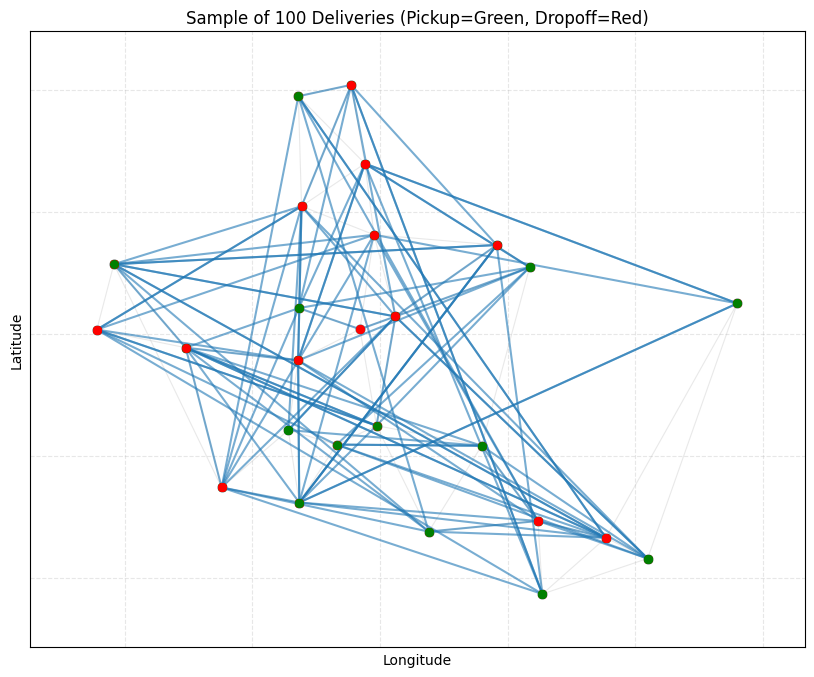

In [47]:
# Example usage (run after generating deliveries)
plot_deliveries_on_graph(G, deliveries, sample_size=100)

In [48]:
## OR Tools part

In [49]:
# -------------------- OR-Tools Sanity Check --------------------
try:
    from ortools.constraint_solver import routing_enums_pb2
    from ortools.constraint_solver import pywrapcp
    print("✅ OR-Tools imported successfully")
except Exception as e:
    print("❌ OR-Tools import failed")
    raise e

✅ OR-Tools imported successfully


In [50]:
# -------------------- OR-Tools Snapshot Extraction --------------------

def extract_ortools_snapshot(env):
    """
    Extract a static snapshot from the environment for OR-Tools.

    Returns:
        snapshot (dict) with:
          - agents: dict[aid] -> current_node
          - deliveries: dict[did] -> (pickup_node, dropoff_node)
          - agent_delivery: dict[aid] -> did (only agents with exactly 1 delivery)
          - distance_matrix: reference to env.distance_matrix
          - node_index: env.node_index
    """
    agents = {}
    deliveries = {}
    agent_delivery = {}

    # Agents with exactly ONE delivery (eligible for bundling)
    for aid, info in env.agents.items():
        agents[aid] = info['current_node']
        if info['state'] == STATE_SINGLE and len(info['deliveries']) == 1:
            agent_delivery[aid] = info['deliveries'][0]

    # Delivery pickup/dropoff
    for did, d in env.delivery_list.by_id.items():
        deliveries[did] = (d.pickup, d.dropoff)

    snapshot = {
        "agents": agents,
        "deliveries": deliveries,
        "agent_delivery": agent_delivery,
        "distance_matrix": env.distance_matrix,
        "node_index": env.node_index,
    }

    return snapshot


# --------- Run snapshot extraction once ---------
snapshot = extract_ortools_snapshot(env)

print("✅ Snapshot extracted")
print(f"Total agents: {len(snapshot['agents'])}")
print(f"Agents with exactly 1 delivery: {len(snapshot['agent_delivery'])}")
print(f"Total deliveries known: {len(snapshot['deliveries'])}")

# Print a tiny sample for sanity
sample_agents = list(snapshot['agent_delivery'].items())[:5]
print("Sample (agent -> delivery):", sample_agents)


✅ Snapshot extracted
Total agents: 100
Agents with exactly 1 delivery: 100
Total deliveries known: 100
Sample (agent -> delivery): [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)]


In [51]:
# -------------------- OR-Tools Distance Callback --------------------

def create_distance_callback(snapshot):
    """
    Create a distance callback compatible with OR-Tools RoutingModel.

    snapshot must contain:
      - distance_matrix
      - node_index
    """
    dist_mat = snapshot["distance_matrix"]
    node_index = snapshot["node_index"]

    # OR-Tools indices are internal; we map them to graph nodes manually
    def distance_callback(from_index, to_index):
        """
        OR-Tools callback: returns distance between two nodes.
        Indices here are routing indices, NOT graph indices.
        We will map them later via RoutingIndexManager.
        """
        # These will be replaced later by proper index mapping
        return 0

    return distance_callback


# --------- Sanity check (no OR-Tools yet) ---------
print("✅ Distance callback factory created (placeholder)")


✅ Distance callback factory created (placeholder)


In [52]:
# -------------------- OR-Tools Routing Model Setup --------------------

def build_routing_model(snapshot):
    """
    Build OR-Tools RoutingIndexManager and RoutingModel.

    We model:
      - one vehicle per agent
      - depot = agent start location (handled via starts[])
    """
    agents = snapshot["agents"]
    node_index = snapshot["node_index"]

    # Number of vehicles = number of agents
    num_vehicles = len(agents)

    # All graph nodes are potential routing nodes
    num_nodes = len(node_index)

    # Vehicle start locations (graph node indices)
    starts = []
    ends = []

    for aid in range(num_vehicles):
        start_node = agents[aid]
        starts.append(node_index[start_node])
        ends.append(node_index[start_node])  # end anywhere; we'll relax later

    manager = pywrapcp.RoutingIndexManager(
        num_nodes,
        num_vehicles,
        starts,
        ends
    )

    routing = pywrapcp.RoutingModel(manager)

    return manager, routing


# --------- Build routing model ---------
manager, routing = build_routing_model(snapshot)

print("✅ RoutingIndexManager and RoutingModel created")
print(f"Vehicles: {routing.vehicles()}")
print(f"Routing nodes: {routing.Size()}")


✅ RoutingIndexManager and RoutingModel created
Vehicles: 100
Routing nodes: 101


In [53]:
# -------------------- OR-Tools Distance Callback Wiring --------------------

def register_distance_callback(snapshot, manager, routing):
    """
    Register a proper distance callback using env.distance_matrix.
    """
    dist_mat = snapshot["distance_matrix"]

    def distance_callback(from_index, to_index):
        # Convert routing indices to node indices
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)

        # Safety check (should never happen)
        if from_node < 0 or to_node < 0:
            return 0

        # Distance from precomputed matrix
        return int(dist_mat[from_node, to_node] * 1000)  # scale to int

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    return transit_callback_index


# --------- Register callback ---------
distance_cb_index = register_distance_callback(snapshot, manager, routing)

print("✅ Distance callback registered and set as cost evaluator")


✅ Distance callback registered and set as cost evaluator


In [54]:
# -------------------- OR-Tools Distance Dimension + Pickup/Delivery (FIXED) --------------------

def add_distance_dimension_and_pickups(snapshot, manager, routing, distance_cb_index):
    """
    Adds:
      1) Distance dimension (required for ordering constraints)
      2) Pickup-dropoff constraints for each agent's assigned delivery
    """
    agent_delivery = snapshot["agent_delivery"]
    deliveries = snapshot["deliveries"]
    node_index = snapshot["node_index"]

    # 1️⃣ Add Distance dimension using the registered distance callback
    routing.AddDimension(
        distance_cb_index,   # transit callback index
        0,                   # no slack
        10**9,               # very large max distance
        True,                # start cumul at zero
        "Distance"
    )

    distance_dim = routing.GetDimensionOrDie("Distance")

    # 2️⃣ Add pickup–delivery constraints
    pair_count = 0

    for aid, did in agent_delivery.items():
        pickup_node, dropoff_node = deliveries[did]

        pickup_idx = manager.NodeToIndex(node_index[pickup_node])
        dropoff_idx = manager.NodeToIndex(node_index[dropoff_node])

        routing.AddPickupAndDelivery(pickup_idx, dropoff_idx)

        # Same vehicle constraint
        routing.solver().Add(
            routing.VehicleVar(pickup_idx) == routing.VehicleVar(dropoff_idx)
        )

        # Pickup before dropoff constraint
        routing.solver().Add(
            distance_dim.CumulVar(pickup_idx) <=
            distance_dim.CumulVar(dropoff_idx)
        )

        pair_count += 1

    print(f"✅ Added distance dimension + {pair_count} pickup-delivery pairs")


# --------- Apply FIXED constraints ---------
add_distance_dimension_and_pickups(snapshot, manager, routing, distance_cb_index)


✅ Added distance dimension + 100 pickup-delivery pairs


In [55]:
# -------------------- OR-Tools Capacity Constraint (Max 2 Deliveries) --------------------

def add_capacity_constraint(snapshot, manager, routing):
    """
    Enforce max 2 deliveries per vehicle.
    Each pickup node consumes 1 unit of capacity.
    """
    node_index = snapshot["node_index"]
    deliveries = snapshot["deliveries"]

    # Identify pickup nodes (graph indices)
    pickup_nodes = set()
    for did, (pickup_node, _) in deliveries.items():
        pickup_nodes.add(node_index[pickup_node])

    # Demand callback
    def demand_callback(from_index):
        node = manager.IndexToNode(from_index)
        return 1 if node in pickup_nodes else 0

    demand_cb_index = routing.RegisterUnaryTransitCallback(demand_callback)

    # Each vehicle has capacity = 2
    routing.AddDimensionWithVehicleCapacity(
        demand_cb_index,
        0,                  # no slack
        [2] * routing.vehicles(),
        True,               # start cumul at zero
        "Capacity"
    )

    print("✅ Capacity constraint added (max 2 deliveries per vehicle)")


# --------- Apply capacity constraint ---------
add_capacity_constraint(snapshot, manager, routing)


✅ Capacity constraint added (max 2 deliveries per vehicle)


In [56]:
# -------------------- OR-Tools Task-Based Model (CORRECT) --------------------

def build_task_based_snapshot(env):
    """
    Build a compact OR-Tools task graph:
      - Nodes = pickups + dropoffs
      - Distances from env.distance_matrix
    """
    tasks = []
    task_index = {}
    index_task = {}

    idx = 0
    for aid, did in snapshot["agent_delivery"].items():
        d = env.delivery_list.by_id[did]
        tasks.append(("pickup", did, d.pickup))
        task_index[("pickup", did)] = idx
        index_task[idx] = ("pickup", did)
        idx += 1

        tasks.append(("dropoff", did, d.dropoff))
        task_index[("dropoff", did)] = idx
        index_task[idx] = ("dropoff", did)
        idx += 1

    num_tasks = len(tasks)
    num_vehicles = env.num_agents

    # Vehicle starts at its pickup node
    starts = []
    ends = []

    for aid in range(num_vehicles):
        if aid in snapshot["agent_delivery"]:
            did = snapshot["agent_delivery"][aid]
            starts.append(task_index[("pickup", did)])
            ends.append(task_index[("dropoff", did)])
        else:
            starts.append(0)
            ends.append(0)

    return {
        "tasks": tasks,
        "task_index": task_index,
        "index_task": index_task,
        "num_tasks": num_tasks,
        "starts": starts,
        "ends": ends,
    }


task_snapshot = build_task_based_snapshot(env)

print("✅ Task-based snapshot created")
print("Tasks:", task_snapshot["num_tasks"])
print("Vehicles:", env.num_agents)


✅ Task-based snapshot created
Tasks: 200
Vehicles: 100


In [57]:
# -------------------- OR-Tools Routing Model (Task-Based) --------------------

def build_task_routing_model(task_snapshot):
    num_tasks = task_snapshot["num_tasks"]
    num_vehicles = len(task_snapshot["starts"])
    starts = task_snapshot["starts"]
    ends = task_snapshot["ends"]

    manager = pywrapcp.RoutingIndexManager(
        num_tasks,
        num_vehicles,
        starts,
        ends
    )

    routing = pywrapcp.RoutingModel(manager)

    return manager, routing


# --------- Build routing model ---------
task_manager, task_routing = build_task_routing_model(task_snapshot)

print("✅ Task-based RoutingModel created")
print(f"Vehicles: {task_routing.vehicles()}")
print(f"Routing nodes: {task_routing.Size()}")


✅ Task-based RoutingModel created
Vehicles: 100
Routing nodes: 100


In [58]:
# -------------------- OR-Tools Task Distance Callback --------------------

def register_task_distance_callback(env, task_snapshot, manager, routing):
    dist_mat = env.distance_matrix
    node_index = env.node_index
    tasks = task_snapshot["tasks"]

    def distance_callback(from_index, to_index):
        from_task = manager.IndexToNode(from_index)
        to_task = manager.IndexToNode(to_index)

        # Safety (dummy node)
        if from_task >= len(tasks) or to_task >= len(tasks):
            return 0

        _, _, from_node = tasks[from_task]
        _, _, to_node = tasks[to_task]

        return int(dist_mat[node_index[from_node], node_index[to_node]] * 1000)

    cb_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(cb_index)

    return cb_index


# --------- Register callback ---------
task_distance_cb = register_task_distance_callback(
    env, task_snapshot, task_manager, task_routing
)

print("✅ Task distance callback registered")


✅ Task distance callback registered


In [1]:
# -------------------- OR-Tools Dimensions (Distance + Capacity) --------------------

def add_dimensions(task_snapshot, manager, routing, distance_cb):
    num_tasks = task_snapshot["num_tasks"]
    tasks = task_snapshot["tasks"]

    # ---- Distance dimension (for ordering pickup -> dropoff) ----
    routing.AddDimension(
        distance_cb,
        0,                  # no slack
        10**9,              # very large max distance
        True,               # start cumul at zero
        "Distance"
    )
    dist_dim = routing.GetDimensionOrDie("Distance")

    # ---- Capacity dimension (max 2 pickups per vehicle) ----
    def demand_callback(from_index):
        task_id = manager.IndexToNode(from_index)
        if task_id >= num_tasks:
            return 0
        task_type, _, _ = tasks[task_id]
        return 1 if task_type == "pickup" else 0

    demand_cb = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_cb,
        0,
        [2] * routing.vehicles(),
        True,
        "Capacity"
    )

    print("✅ Distance + Capacity dimensions added")
    return dist_dim


In [59]:
# -------------------- Pickup–Dropoff Constraints (SAFE) --------------------

def add_pickup_dropoff_constraints(task_snapshot, manager, routing, dist_dim):
    task_index = task_snapshot["task_index"]

    pair_count = 0
    for (kind, did), p_idx in task_index.items():
        if kind != "pickup":
            continue

        d_idx = task_index[("dropoff", did)]

        p = manager.NodeToIndex(p_idx)
        d = manager.NodeToIndex(d_idx)

        # Same vehicle
        routing.solver().Add(
            routing.VehicleVar(p) == routing.VehicleVar(d)
        )

        # Pickup before dropoff
        routing.solver().Add(
            dist_dim.CumulVar(p) <= dist_dim.CumulVar(d)
        )

        pair_count += 1

    print(f"✅ Added {pair_count} pickup→dropoff precedence constraints")


In [60]:
# -------------------- Solve OR-Tools Model --------------------

def solve_task_vrp(routing):
    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GREEDY_DESCENT
    )
    search_params.time_limit.seconds = 5
    search_params.log_search = False

    print("🚀 Solving OR-Tools task-based VRP...")
    solution = routing.SolveWithParameters(search_params)

    if solution is None:
        print("❌ OR-Tools failed — falling back to no bundles")
        return None

    print("✅ OR-Tools solved successfully")
    return solution


In [61]:
# -------------------- Extract Assignment --------------------

def extract_assignment(solution, task_snapshot, manager, routing):
    assignments = {v: [] for v in range(routing.vehicles())}
    tasks = task_snapshot["tasks"]

    for v in range(routing.vehicles()):
        idx = routing.Start(v)
        while not routing.IsEnd(idx):
            task_id = manager.IndexToNode(idx)
            if task_id < len(tasks):
                kind, did, _ = tasks[task_id]
                if kind == "pickup":
                    assignments[v].append(did)
            idx = solution.Value(routing.NextVar(idx))

    # Remove empty vehicles
    assignments = {k: v for k, v in assignments.items() if v}
    print(f"✅ Extracted assignments for {len(assignments)} drivers")
    return assignments


In [62]:
# -------------------- Apply Assignment to Environment --------------------

def apply_assignment_to_env(env, assignments):
    for aid, delivery_ids in assignments.items():
        if not delivery_ids:
            continue

        agent = env.agents[aid]
        agent["deliveries"] = []
        agent["path_queue"] = []
        agent["state"] = STATE_IDLE

        for did in delivery_ids:
            d = env.delivery_list.by_id[did]
            d.assign_to_agent(aid)
            d.spawn_time = 0.0
            d.pickup_time = 0.0
            agent["deliveries"].append(did)

        agent["state"] = STATE_SINGLE if len(delivery_ids) == 1 else STATE_DOUBLE

    print("✅ Assignment applied to environment")


In [ ]:
# -------------------- Run Simulation --------------------

env.reset()

while True:
    _, _, done, info = env.step()
    if done:
        break

print("🏁 Simulation completed")


In [ ]:
# -------------------- Save Metrics --------------------

import json
from pathlib import Path

output_path = Path(output_dir) / "ortools_results.json"

results = {
    "episode_stats": env.episode_stats,
    "deliveries": env.delivery_list.to_simple_list(),
    "timeline": env.timeline,
}

with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"📁 Results saved to: {output_path}")